<a href="https://colab.research.google.com/github/THEFOOL-I/FINAL-CAPSTONE-PROJECT/blob/main/FINALPROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
#data ingestion
df=pd.read_csv("P_8_city_day.csv")
#seeing first five rows of dataset
df.head(5)

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [3]:
#checking dataset shape
df.shape

(18265, 16)

In [4]:
#INTERPRETATION
#The dataset contains 18,265 observations and 16 variables, providing daily air-quality measurements across five cities over the period from 2015 to 2024.

In [5]:
#Inspecting column names
df.columns

Index(['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [6]:
#checking datatypes of all features
df.dtypes

,0
City,object
Datetime,object
PM2.5,float64
PM10,float64
NO,float64
NO2,float64
NOx,float64
NH3,float64
CO,float64
SO2,float64


In [7]:
#Important finding
#Datetime is currently stored as an object, so we will convert its datatype to datetime in the cleaning steps.

In [8]:
#Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        18265 non-null  object 
 1   Datetime    18265 non-null  object 
 2   PM2.5       18265 non-null  float64
 3   PM10        18265 non-null  float64
 4   NO          18265 non-null  float64
 5   NO2         18265 non-null  float64
 6   NOx         18265 non-null  float64
 7   NH3         18265 non-null  float64
 8   CO          18265 non-null  float64
 9   SO2         18265 non-null  float64
 10  O3          18265 non-null  float64
 11  Benzene     18265 non-null  float64
 12  Toluene     18265 non-null  float64
 13  Xylene      18265 non-null  float64
 14  AQI         18265 non-null  float64
 15  AQI_Bucket  18265 non-null  object 
dtypes: float64(13), object(3)
memory usage: 2.2+ MB


In [9]:
#Basic statistical overview of the dataset
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000
mean,250.597695,299.442491,100.481035,75.415916,125.964079,25.065042,5.002451,49.835839,100.406740,10.070033,15.063365,4.996341,251.111382
std,144.460292,173.479906,57.774795,43.460066,72.403893,14.452019,2.889439,28.988739,57.591436,5.785282,8.619433,2.899152,144.502626
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,125.700000,150.100000,50.600000,37.700000,63.100000,12.600000,2.490000,24.400000,50.600000,5.080000,7.640000,2.510000,125.400000
50%,251.000000,300.300000,100.200000,76.000000,126.200000,25.300000,5.000000,49.900000,100.700000,10.080000,15.130000,4.960000,251.200000
75%,376.200000,450.000000,151.000000,113.200000,188.900000,37.600000,7.510000,75.100000,150.400000,15.110000,22.500000,7.530000,376.400000
max,499.900000,600.000000,200.000000,150.000000,250.000000,50.000000,10.000000,100.000000,200.000000,20.000000,30.000000,10.000000,500.000000


In [10]:
#checking cities
print(df['City'].unique())

['Delhi' 'Mumbai' 'Chennai' 'Kolkata' 'Bangalore']


In [11]:
#checking data range
df['Datetime'] = pd.to_datetime(df['Datetime'])
print("Start date:", df['Datetime'].min())
print("End date:", df['Datetime'].max())

Start date: 2015-01-01 00:00:00
End date: 2024-12-31 00:00:00


In [12]:
#So we have approximately 10 years of daily observations.

In [13]:
#Check missing values
df.isnull().sum()

,0
City,0
Datetime,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


In [14]:
#There are no missing values in the dataset.

In [15]:
#Checking duplicates
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [17]:
#checking duplicates specifically by city and date:
print(
    "Duplicate City-Datetime records:",
    df.duplicated(subset=['City', 'Datetime']).sum()
)

Duplicate City-Datetime records: 0


In [18]:
#Checking categorical values
print("Cities:")
print(df['City'].value_counts())
print("\nAQI Buckets:")
print(df['AQI_Bucket'].value_counts())

Cities:
City
Delhi        3653
Mumbai       3653
Chennai      3653
Kolkata      3653
Bangalore    3653
Name: count, dtype: int64

AQI Buckets:
AQI_Bucket
Severe          3121
Satisfactory    3098
Good            3094
Poor            3016
Very Poor       2989
Moderate        2947
Name: count, dtype: int64


In [19]:
#Checking invalid negative values
numeric_columns = df.select_dtypes(include=np.number).columns
negative_values = (df[numeric_columns] < 0).sum()
print(negative_values)

PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
AQI        0
dtype: int64


In [20]:
#No negative pollutant concentrations or negative AQI values were detected.

In [21]:
#Checking AQI range
print("Minimum AQI:", df['AQI'].min())
print("Maximum AQI:", df['AQI'].max())

Minimum AQI: 0.0
Maximum AQI: 500.0


In [22]:
df_clean = df.copy()
print("Original shape:", df.shape)
print("Cleaning copy shape:", df_clean.shape)

Original shape: (18265, 16)
Cleaning copy shape: (18265, 16)


In [23]:
#Converting Datetime to datetime format
df_clean['Datetime'] = pd.to_datetime(df_clean['Datetime'])
print(df_clean.dtypes)

City                  object
Datetime      datetime64[ns]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
Xylene               float64
AQI                  float64
AQI_Bucket            object
dtype: object


In [24]:
missing_summary = pd.DataFrame({
    'Missing Values': df_clean.isnull().sum(),
    'Missing Percentage': (df_clean.isnull().sum() / len(df_clean)) * 100
})
missing_summary

,Missing Values,Missing Percentage
City,0,0.0
Datetime,0,0.0
PM2.5,0,0.0
PM10,0,0.0
NO,0,0.0
NO2,0,0.0
NOx,0,0.0
NH3,0,0.0
CO,0,0.0
SO2,0,0.0


In [25]:
#No missing values were detected in any column. Therefore, no imputation or row deletion was required.

In [26]:
duplicate_count = df_clean.duplicated().sum()
print("Duplicate records found:", duplicate_count)

Duplicate records found: 0


In [27]:
#Checking duplicate City with Datetime combinations
city_date_duplicates = df_clean.duplicated(
    subset=['City', 'Datetime']
).sum()
print("Duplicate City-Datetime records:", city_date_duplicates)

Duplicate City-Datetime records: 0


In [28]:
#Checking inconsistent categorical values
print("Unique City values:")
print(df_clean['City'].unique())
print("\nUnique AQI_Bucket values:")
print(df_clean['AQI_Bucket'].unique())

Unique City values:
['Delhi' 'Mumbai' 'Chennai' 'Kolkata' 'Bangalore']

Unique AQI_Bucket values:
['Severe' 'Satisfactory' 'Very Poor' 'Good' 'Moderate' 'Poor']


In [29]:
#Checking invalid negative values
numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns
negative_values = (df_clean[numeric_columns] < 0).sum()
negative_values

,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0
O3,0
Benzene,0


In [30]:
#Validating the AQI range
invalid_aqi = (
    (df_clean['AQI'] < 0) |
    (df_clean['AQI'] > 500)
).sum()

print("AQI values outside 0-500:", invalid_aqi)


AQI values outside 0-500: 0


In [31]:
#Checking whether all dates converted correctly
invalid_dates = df_clean['Datetime'].isna().sum()
print("Invalid dates after conversion:", invalid_dates)

Invalid dates after conversion: 0


In [32]:
#Outlier detection using IQR
outlier_summary = []

for column in numeric_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ).sum()
    outlier_summary.append([
        column,
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        outliers
    ])
outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        'Column',
        'Q1',
        'Q3',
        'IQR',
        'Lower Bound',
        'Upper Bound',
        'Outlier Count'
    ]
)
outlier_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,PM2.5,125.70,376.20,250.50,-250.050,751.950,0
1,PM10,150.10,450.00,299.90,-299.750,899.850,0
2,NO,50.60,151.00,100.40,-100.000,301.600,0
3,NO2,37.70,113.20,75.50,-75.550,226.450,0
4,NOx,63.10,188.90,125.80,-125.600,377.600,0
5,NH3,12.60,37.60,25.00,-24.900,75.100,0
6,CO,2.49,7.51,5.02,-5.040,15.040,0
7,SO2,24.40,75.10,50.70,-51.650,151.150,0
8,O3,50.60,150.40,99.80,-99.100,300.100,0
9,Benzene,5.08,15.11,10.03,-9.965,30.155,0


In [33]:
#Final validation after cleaning
print("Final dataset shape:", df_clean.shape)
print("Total missing values:", df_clean.isnull().sum().sum())
print("Total duplicate rows:", df_clean.duplicated().sum())
print("Invalid dates:", df_clean['Datetime'].isna().sum())
print("Negative numerical values:", (df_clean[numeric_columns] < 0).sum().sum())
print(
    "AQI values outside 0-500:",
    ((df_clean['AQI'] < 0) | (df_clean['AQI'] > 500)).sum()
)

Final dataset shape: (18265, 16)
Total missing values: 0
Total duplicate rows: 0
Invalid dates: 0
Negative numerical values: 0
AQI values outside 0-500: 0


In [34]:
before_after = pd.DataFrame({
    'Quality Check': [
        'Rows',
        'Columns',
        'Missing Values',
        'Duplicate Rows',
        'Duplicate City-Datetime',
        'Invalid Dates',
        'Negative Numerical Values',
        'Invalid AQI Values'
    ],

    'Before Cleaning': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df.duplicated(['City', 'Datetime']).sum(),
        pd.to_datetime(df['Datetime'], errors='coerce').isna().sum(),
        (df[numeric_columns] < 0).sum().sum(),
        ((df['AQI'] < 0) | (df['AQI'] > 500)).sum()
    ],

    'After Cleaning': [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum(),
        df_clean.duplicated(['City', 'Datetime']).sum(),
        df_clean['Datetime'].isna().sum(),
        (df_clean[numeric_columns] < 0).sum().sum(),
        ((df_clean['AQI'] < 0) | (df_clean['AQI'] > 500)).sum()
    ]
})

before_after

,Quality Check,Before Cleaning,After Cleaning
0,Rows,18265,18265
1,Columns,16,16
2,Missing Values,0,0
3,Duplicate Rows,0,0
4,Duplicate City-Datetime,0,0
5,Invalid Dates,0,0
6,Negative Numerical Values,0,0
7,Invalid AQI Values,0,0


In [35]:
df_clean.to_csv('P_8_city_day_cleaned.csv', index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [36]:
#DATA PREPROCESSING

In [37]:
#Creating time-based features
df_clean['Year'] = df_clean['Datetime'].dt.year
df_clean['Month'] = df_clean['Datetime'].dt.month
df_clean['Day'] = df_clean['Datetime'].dt.day
df_clean['DayOfWeek'] = df_clean['Datetime'].dt.dayofweek

df_clean.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day,DayOfWeek
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe,2015,1,1,3
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory,2015,1,1,3
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe,2015,1,1,3
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor,2015,1,1,3
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good,2015,1,1,3


In [38]:
#Verifying the new features
print("New time-based features:")
print(df_clean[['Datetime', 'Year', 'Month', 'Day', 'DayOfWeek']].head())

New time-based features:
    Datetime  Year  Month  Day  DayOfWeek
0 2015-01-01  2015      1    1          3
1 2015-01-01  2015      1    1          3
2 2015-01-01  2015      1    1          3
3 2015-01-01  2015      1    1          3
4 2015-01-01  2015      1    1          3


In [42]:
#Checking whether the time features are created correctly
print("Year range:", df_clean['Year'].min(), "-", df_clean['Year'].max())
print("Month range:", df_clean['Month'].min(), "-", df_clean['Month'].max())
print("Day range:", df_clean['Day'].min(), "-", df_clean['Day'].max())
print("DayOfWeek range:", df_clean['DayOfWeek'].min(), "-", df_clean['DayOfWeek'].max())

Year range: 2015 - 2024
Month range: 1 - 12
Day range: 1 - 31
DayOfWeek range: 0 - 6


In [43]:
#Defining the target
target = 'AQI'
print("Target variable:", target)

Target variable: AQI


In [45]:
#Identifying the columns that must NOT be used
#AQI is our target, so it cannot be an input feature.
#AQI_Bucket also be excluded because it would create target leakage.
# DateTime also because we have already extracted useful time information from it, so the raw datetime itself isn't needed as a numerical model feature.

In [46]:
#Defining the feature columns
feature_columns = [
    'City',
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'Benzene',
    'Toluene',
    'Xylene',
    'Year',
    'Month',
    'Day',
    'DayOfWeek'
]
print("Number of features:", len(feature_columns))
print("\nFeatures:")
for feature in feature_columns:
    print(feature)

Number of features: 17

Features:
City
PM2.5
PM10
NO
NO2
NOx
NH3
CO
SO2
O3
Benzene
Toluene
Xylene
Year
Month
Day
DayOfWeek


In [47]:
#Creating X and y
X = df_clean[feature_columns]
y = df_clean[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (18265, 17)
y shape: (18265,)


In [48]:
#Verifying that target leakage is not present
print("AQI in features:", 'AQI' in X.columns)
print("AQI_Bucket in features:", 'AQI_Bucket' in X.columns)

AQI in features: False
AQI_Bucket in features: False


In [49]:
#Separating numerical and categorical features
categorical_features = ['City']

numerical_features = [
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'Benzene',
    'Toluene',
    'Xylene',
    'Year',
    'Month',
    'Day',
    'DayOfWeek'
]

print("Categorical features:", categorical_features)
print("\nNumber of numerical features:", len(numerical_features))

Categorical features: ['City']

Number of numerical features: 16


In [50]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14612, 17)
X_test shape: (3653, 17)
y_train shape: (14612,)
y_test shape: (3653,)


In [51]:
#Creating the preprocessing pipeline
#Numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [52]:
#Fit preprocessing ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data processed successfully.")
print("Testing data processed successfully.")

Training data processed successfully.
Testing data processed successfully.


In [53]:
#Checking processed dimensions
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (14612, 21)
Processed X_test shape: (3653, 21)


In [54]:
#Getting the encoded feature names
encoded_city_features = preprocessor.named_transformers_[
    'cat'
].get_feature_names_out(categorical_features)

final_feature_names = numerical_features + list(encoded_city_features)

print("Final number of features:", len(final_feature_names))

print("\nFinal features:")
for feature in final_feature_names:
    print(feature)

Final number of features: 21

Final features:
PM2.5
PM10
NO
NO2
NOx
NH3
CO
SO2
O3
Benzene
Toluene
Xylene
Year
Month
Day
DayOfWeek
City_Bangalore
City_Chennai
City_Delhi
City_Kolkata
City_Mumbai


In [55]:
#Final preprocessing verification
print("Original observations:", len(df_clean))
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nOriginal feature count:", len(feature_columns))
print("Processed feature count:", len(final_feature_names))

print("\nTarget:", target)
print("Target excluded from X:", target not in X.columns)
print("AQI_Bucket excluded:", 'AQI_Bucket' not in X.columns)

Original observations: 18265
Training observations: 14612
Testing observations: 3653

Original feature count: 17
Processed feature count: 21

Target: AQI
Target excluded from X: True
AQI_Bucket excluded: True


In [56]:
#Creating folders for EDA outputs
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

In [57]:
#EDA dataset overview
print("Dataset Shape:", df_clean.shape)

print("\nColumn Names:")
print(df_clean.columns.tolist())

print("\nData Types:")
print(df_clean.dtypes)

print("\nMissing Values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

Dataset Shape: (18265, 20)

Column Names:
['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Year', 'Month', 'Day', 'DayOfWeek']

Data Types:
City                  object
Datetime      datetime64[ns]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
Xylene               float64
AQI                  float64
AQI_Bucket            object
Year                   int32
Month                  int32
Day                    int32
DayOfWeek              int32
dtype: object

Missing Values:
0

Duplicate Rows:
0


In [58]:
#Descriptive Statistics
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Datetime,18265,2020-01-01 00:00:00,2015-01-01 00:00:00,2017-07-02 00:00:00,2020-01-01 00:00:00,2022-07-02 00:00:00,2024-12-31 00:00:00,NaN
PM2.5,18265.0,250.597695,0.0,125.7,251.0,376.2,499.9,144.460292
PM10,18265.0,299.442491,0.0,150.1,300.3,450.0,600.0,173.479906
NO,18265.0,100.481035,0.0,50.6,100.2,151.0,200.0,57.774795
NO2,18265.0,75.415916,0.0,37.7,76.0,113.2,150.0,43.460066
NOx,18265.0,125.964079,0.0,63.1,126.2,188.9,250.0,72.403893
NH3,18265.0,25.065042,0.0,12.6,25.3,37.6,50.0,14.452019
CO,18265.0,5.002451,0.0,2.49,5.0,7.51,10.0,2.889439
SO2,18265.0,49.835839,0.0,24.4,49.9,75.1,100.0,28.988739
O3,18265.0,100.40674,0.0,50.6,100.7,150.4,200.0,57.591436


In [59]:
#City-wise observation count
city_counts = df_clean['City'].value_counts()

print(city_counts)

City
Delhi        3653
Mumbai       3653
Chennai      3653
Kolkata      3653
Bangalore    3653
Name: count, dtype: int64


In [60]:
#AQI statistics by city
aqi_by_city = df_clean.groupby('City')['AQI'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).sort_values('mean', ascending=False)

aqi_by_city

,count,mean,median,std,min,max
City,,,,,,
Mumbai,3653,253.319053,254.4,145.375846,0.0,500.0
Delhi,3653,251.496304,257.2,143.665915,0.2,499.9
Kolkata,3653,250.635396,249.5,144.285499,0.1,499.9
Chennai,3653,250.338763,248.6,144.896657,0.3,499.8
Bangalore,3653,249.767397,247.8,144.336008,0.1,499.9


In [61]:
#Save city-wise AQI statistics
aqi_by_city.to_csv('outputs/aqi_by_city.csv')

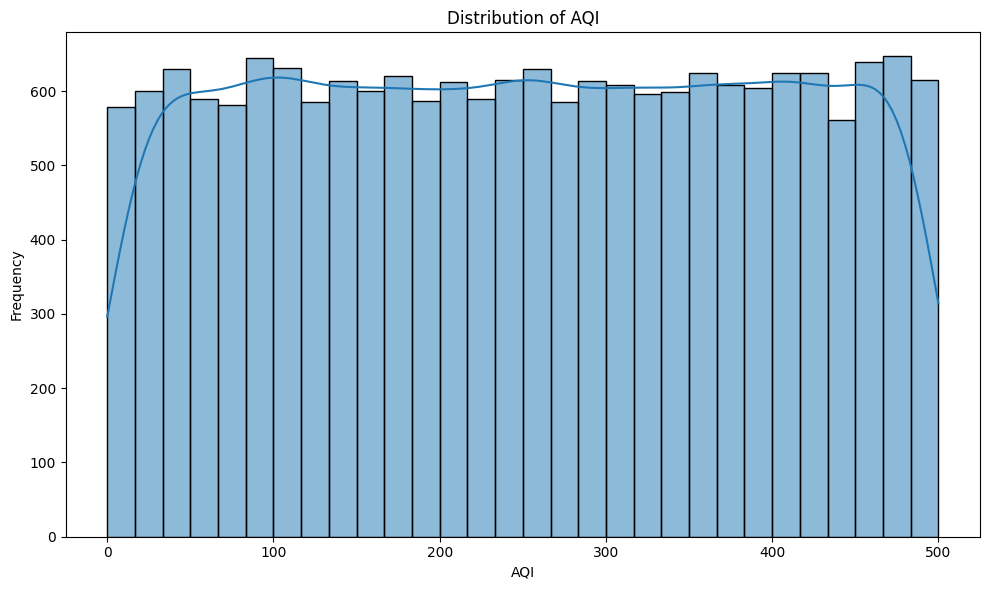

In [62]:
#EDA
#Overall AQI distribution
plt.figure(figsize=(10, 6))

sns.histplot(df_clean['AQI'], bins=30, kde=True)

plt.title('Distribution of AQI')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.tight_layout()

plt.savefig('figures/figure_1_aqi_distribution.png', dpi=300)
plt.show()

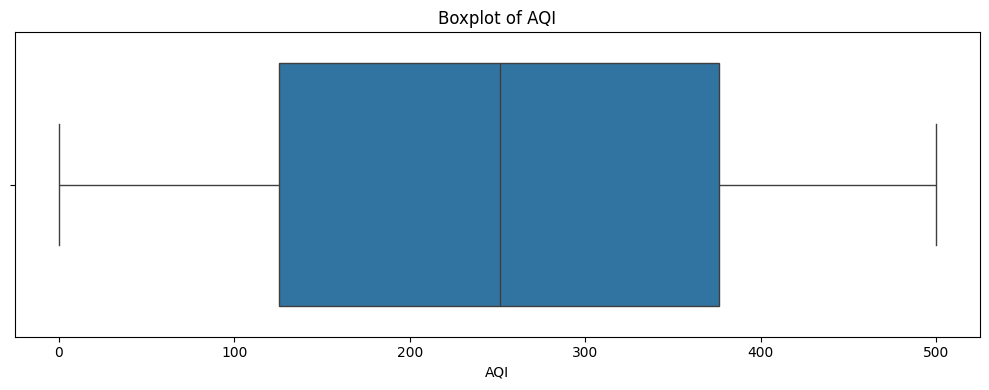

In [63]:
#AQI distribution using boxplot
plt.figure(figsize=(10, 4))

sns.boxplot(x=df_clean['AQI'])

plt.title('Boxplot of AQI')
plt.xlabel('AQI')
plt.tight_layout()

plt.savefig('figures/figure_2_aqi_boxplot.png', dpi=300)
plt.show()

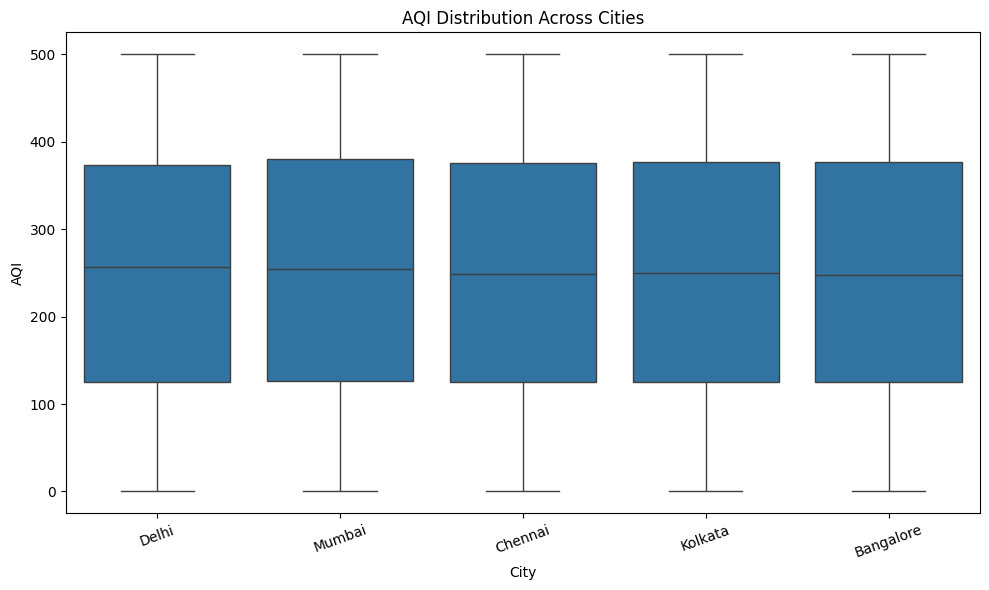

In [64]:
#AQI comparison across cities
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_clean, x='City', y='AQI')

plt.title('AQI Distribution Across Cities')
plt.xlabel('City')
plt.ylabel('AQI')
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig('figures/figure_3_aqi_by_city.png', dpi=300)
plt.show()

In [65]:
#Annual AQI trend
yearly_aqi = df_clean.groupby(
    df_clean['Datetime'].dt.year
)['AQI'].mean()

print(yearly_aqi.round(3))

Datetime
2015    247.418
2016    250.106
2017    250.887
2018    246.312
2019    255.430
2020    247.308
2021    252.503
2022    250.474
2023    257.006
2024    253.676
Name: AQI, dtype: float64


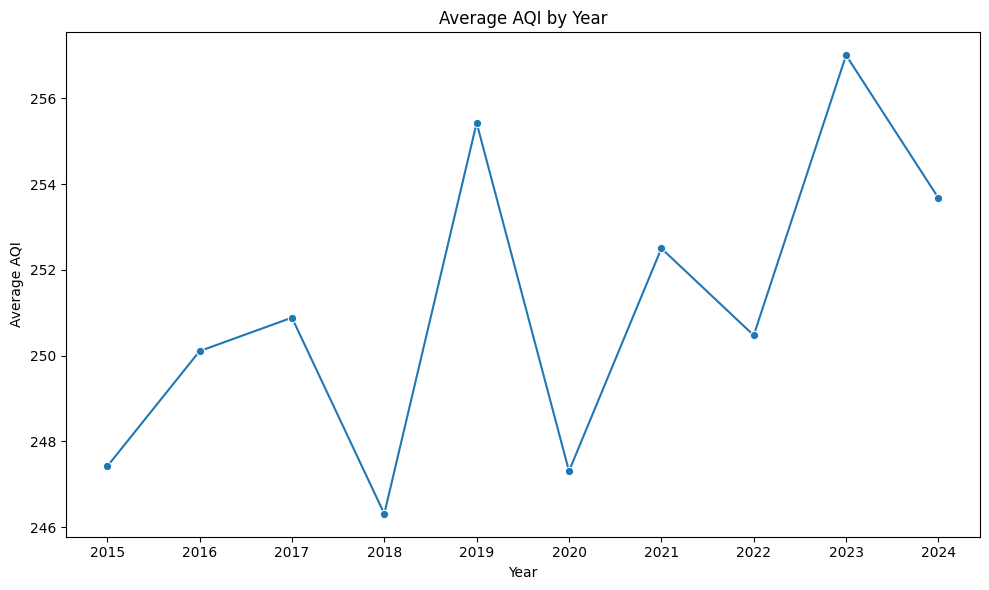

In [66]:
#Plot annual AQI trend
plt.figure(figsize=(10, 6))

sns.lineplot(
    x=yearly_aqi.index,
    y=yearly_aqi.values,
    marker='o'
)

plt.title('Average AQI by Year')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.xticks(yearly_aqi.index)
plt.tight_layout()

plt.savefig('figures/figure_4_yearly_aqi_trend.png', dpi=300)
plt.show()

In [67]:
#Monthly AQI pattern
monthly_aqi = df_clean.groupby(
    df_clean['Datetime'].dt.month
)['AQI'].mean()

print(monthly_aqi.round(3))

Datetime
1     253.238
2     253.796
3     255.818
4     253.542
5     248.512
6     249.752
7     245.607
8     252.173
9     248.349
10    248.108
11    250.010
12    254.575
Name: AQI, dtype: float64


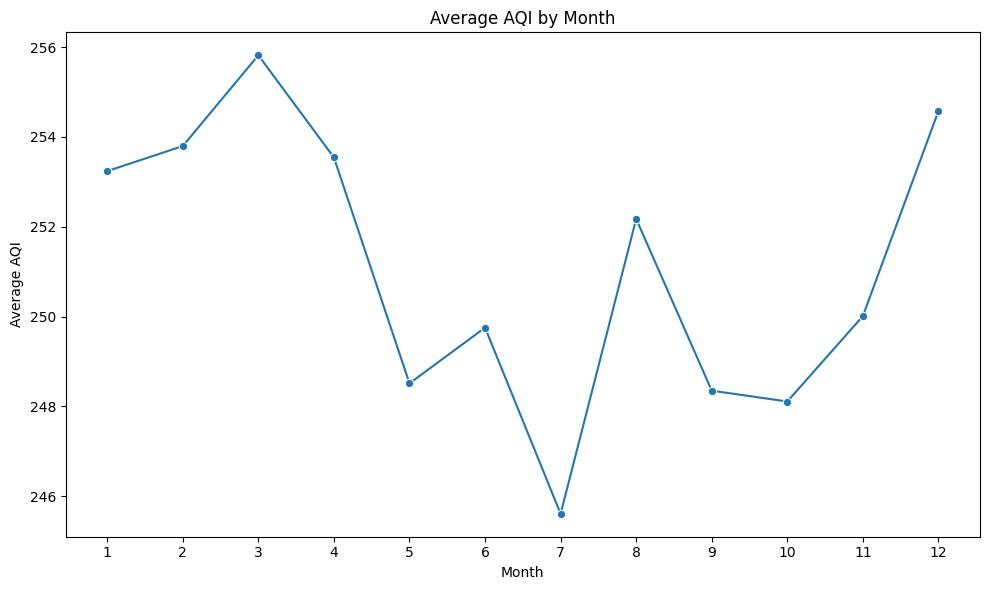

In [68]:
#Plot monthly AQI pattern
plt.figure(figsize=(10, 6))

sns.lineplot(
    x=monthly_aqi.index,
    y=monthly_aqi.values,
    marker='o'
)

plt.title('Average AQI by Month')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(range(1, 13))
plt.tight_layout()

plt.savefig('figures/figure_5_monthly_aqi_pattern.png', dpi=300)
plt.show()

In [69]:
#AQI and pollutant correlation
pollutant_columns = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
    'NH3', 'CO', 'SO2', 'O3',
    'Benzene', 'Toluene', 'Xylene'
]

aqi_correlations = df_clean[pollutant_columns + ['AQI']].corr()['AQI'] \
    .drop('AQI') \
    .sort_values(ascending=False)

print(aqi_correlations)

NO2        0.011124
Xylene     0.010412
Toluene    0.009428
NH3        0.008079
CO         0.006046
SO2        0.002949
NO         0.001923
PM10       0.001245
PM2.5      0.000655
O3         0.000591
Benzene   -0.001251
NOx       -0.002662
Name: AQI, dtype: float64


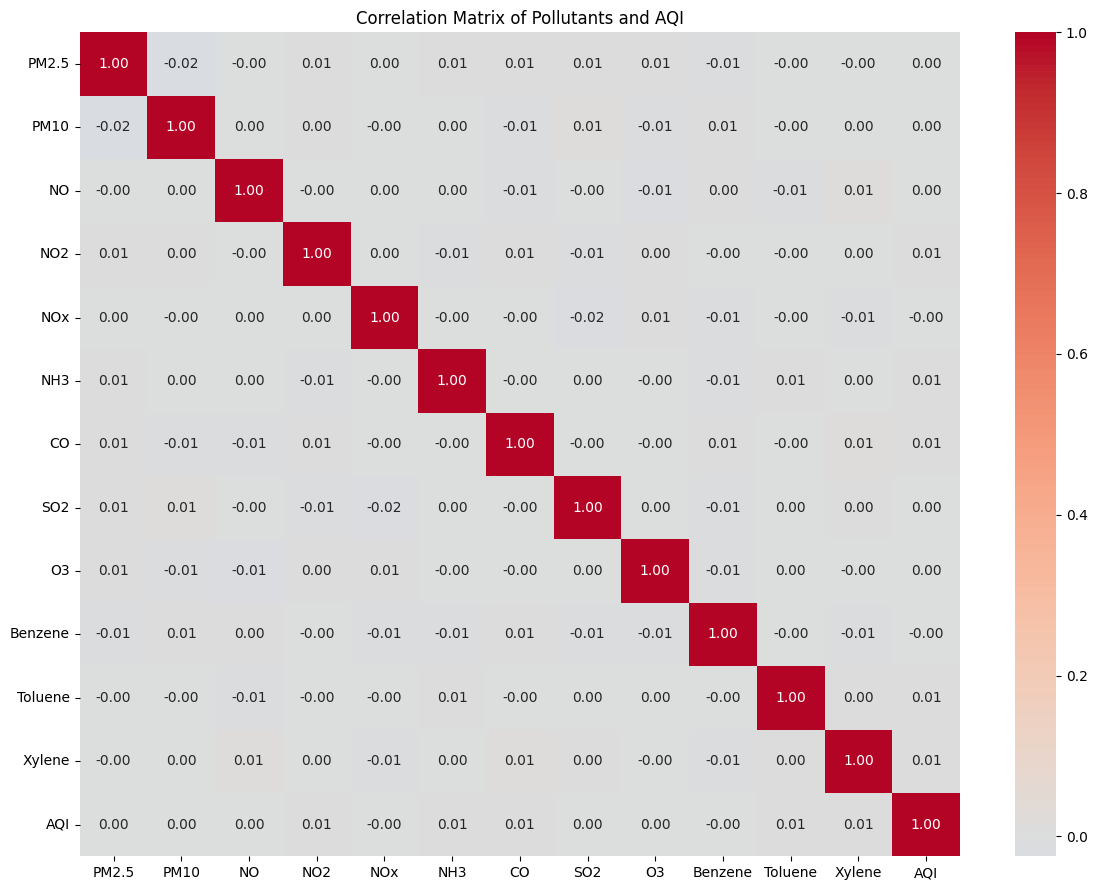

In [70]:
#Correlation heatmap
correlation_data = df_clean[pollutant_columns + ['AQI']].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_data,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Pollutants and AQI')
plt.tight_layout()

plt.savefig('figures/figure_6_pollutant_aqi_correlation.png', dpi=300)
plt.show()

In [71]:
#Strongest pollutant relationships with AQI
print("Strongest positive correlation:")
print(aqi_correlations.idxmax(), "=", round(aqi_correlations.max(), 4))

print("\nStrongest negative correlation:")
print(aqi_correlations.idxmin(), "=", round(aqi_correlations.min(), 4))

Strongest positive correlation:
NO2 = 0.0111

Strongest negative correlation:
NOx = -0.0027


In [73]:
#Statistical Analysis
#Importing statistical testing tools
from scipy import stats
#Descriptive statistics for AQI
aqi_stats = df_clean['AQI'].describe()

print("AQI Descriptive Statistics")
print("--------------------------")
print("Count:", int(aqi_stats['count']))
print("Mean:", round(aqi_stats['mean'], 3))
print("Median:", round(df_clean['AQI'].median(), 3))
print("Standard Deviation:", round(aqi_stats['std'], 3))
print("Minimum:", round(aqi_stats['min'], 3))
print("Maximum:", round(aqi_stats['max'], 3))
print("Q1:", round(aqi_stats['25%'], 3))
print("Q3:", round(aqi_stats['75%'], 3))

AQI Descriptive Statistics
--------------------------
Count: 18265
Mean: 251.111
Median: 251.2
Standard Deviation: 144.503
Minimum: 0.0
Maximum: 500.0
Q1: 125.4
Q3: 376.4


In [74]:
mumbai_aqi = df_clean[df_clean['City'] == 'Mumbai']['AQI']
delhi_aqi = df_clean[df_clean['City'] == 'Delhi']['AQI']
kolkata_aqi = df_clean[df_clean['City'] == 'Kolkata']['AQI']
chennai_aqi = df_clean[df_clean['City'] == 'Chennai']['AQI']
bangalore_aqi = df_clean[df_clean['City'] == 'Bangalore']['AQI']

f_stat, p_value = stats.f_oneway(
    mumbai_aqi,
    delhi_aqi,
    kolkata_aqi,
    chennai_aqi,
    bangalore_aqi
)

print("ANOVA F-statistic:", f_stat)
print("ANOVA p-value:", p_value)

ANOVA F-statistic: 0.3346086488302743
ANOVA p-value: 0.8548174642736214


In [75]:
#Correlation summary
correlation_summary = pd.DataFrame({
    'Pollutant': aqi_correlations.index,
    'Correlation_with_AQI': aqi_correlations.values
})

correlation_summary

,Pollutant,Correlation_with_AQI
0,NO2,0.011124
1,Xylene,0.010412
2,Toluene,0.009428
3,NH3,0.008079
4,CO,0.006046
5,SO2,0.002949
6,NO,0.001923
7,PM10,0.001245
8,PM2.5,0.000655
9,O3,0.000591


In [76]:
#Save statistical analysis results
aqi_stats.to_csv('outputs/aqi_descriptive_statistics.csv')

correlation_summary.to_csv(
    'outputs/aqi_correlation_summary.csv',
    index=False
)

anova_results = pd.DataFrame({
    'Test': ['One-way ANOVA'],
    'F_statistic': [f_stat],
    'p_value': [p_value]
})

anova_results.to_csv(
    'outputs/anova_city_aqi.csv',
    index=False
)

In [77]:
#Feature Engineering
#Review the engineered time features
time_features = [
    'Year',
    'Month',
    'Day',
    'DayOfWeek'
]

df_clean[time_features].head(10)

,Year,Month,Day,DayOfWeek
0,2015,1,1,3
1,2015,1,1,3
2,2015,1,1,3
3,2015,1,1,3
4,2015,1,1,3
5,2015,1,2,4
6,2015,1,2,4
7,2015,1,2,4
8,2015,1,2,4
9,2015,1,2,4


In [78]:
#Checking the range of time features
print("Year range:", df_clean['Year'].min(), "to", df_clean['Year'].max())
print("Month range:", df_clean['Month'].min(), "to", df_clean['Month'].max())
print("Day range:", df_clean['Day'].min(), "to", df_clean['Day'].max())
print("DayOfWeek range:", df_clean['DayOfWeek'].min(), "to", df_clean['DayOfWeek'].max())

Year range: 2015 to 2024
Month range: 1 to 12
Day range: 1 to 31
DayOfWeek range: 0 to 6


In [79]:
#Check whether any engineered features contain missing values
print("Missing values in engineered features:")
print(df_clean[time_features].isnull().sum())

Missing values in engineered features:
Year         0
Month        0
Day          0
DayOfWeek    0
dtype: int64


In [80]:
#feature-engineering summary
feature_engineering_summary = pd.DataFrame({
    'Feature': [
        'Year',
        'Month',
        'Day',
        'DayOfWeek'
    ],
    'Source': [
        'Datetime',
        'Datetime',
        'Datetime',
        'Datetime'
    ],
    'Purpose': [
        'Capture long-term yearly variation',
        'Capture seasonal/monthly variation',
        'Capture within-month temporal variation',
        'Capture weekly variation'
    ]
})

feature_engineering_summary

,Feature,Source,Purpose
0,Year,Datetime,Capture long-term yearly variation
1,Month,Datetime,Capture seasonal/monthly variation
2,Day,Datetime,Capture within-month temporal variation
3,DayOfWeek,Datetime,Capture weekly variation


In [81]:
feature_engineering_summary.to_csv(
    'outputs/feature_engineering_summary.csv',
    index=False
)

In [82]:
#Model Development
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [83]:
#Creating Linear Regression pipeline
linear_regression_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [84]:
#Training Linear Regression
linear_regression_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [85]:
#Creating Random Forest Regressor pipeline
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [86]:
#Training Random Forest
random_forest_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


In [87]:
#generating predictions from both models
y_pred_linear = linear_regression_model.predict(X_test)
y_pred_rf = random_forest_model.predict(X_test)

print("Predictions generated successfully.")
print("Linear Regression predictions:", len(y_pred_linear))
print("Random Forest predictions:", len(y_pred_rf))

Predictions generated successfully.
Linear Regression predictions: 3653
Random Forest predictions: 3653


In [88]:
#Calculating regression metrics
def evaluate_regression_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }


linear_results = evaluate_regression_model(
    'Linear Regression',
    y_test,
    y_pred_linear
)

rf_results = evaluate_regression_model(
    'Random Forest Regressor',
    y_test,
    y_pred_rf
)

results = pd.DataFrame([
    linear_results,
    rf_results
])

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,124.717032,20842.602336,144.369672,-0.001619
1,Random Forest Regressor,125.486999,21198.376072,145.596621,-0.018716


In [89]:
results.to_csv(
    'outputs/model_evaluation_results.csv',
    index=False
)

In [90]:
#Comparing actual vs predicted AQI
prediction_comparison = pd.DataFrame({
    'Actual_AQI': y_test.values,
    'Linear_Regression_Predicted': y_pred_linear,
    'Random_Forest_Predicted': y_pred_rf
})

prediction_comparison.head(10)

,Actual_AQI,Linear_Regression_Predicted,Random_Forest_Predicted
0,203.6,250.243100,251.100
1,35.6,255.602844,242.518
2,137.5,251.978684,247.367
3,91.4,247.744399,232.206
4,455.4,251.573244,265.015
5,377.8,252.230344,273.142
6,426.9,249.232829,236.135
7,134.0,255.617631,282.782
8,339.1,248.293643,232.834
9,96.0,243.707147,264.665


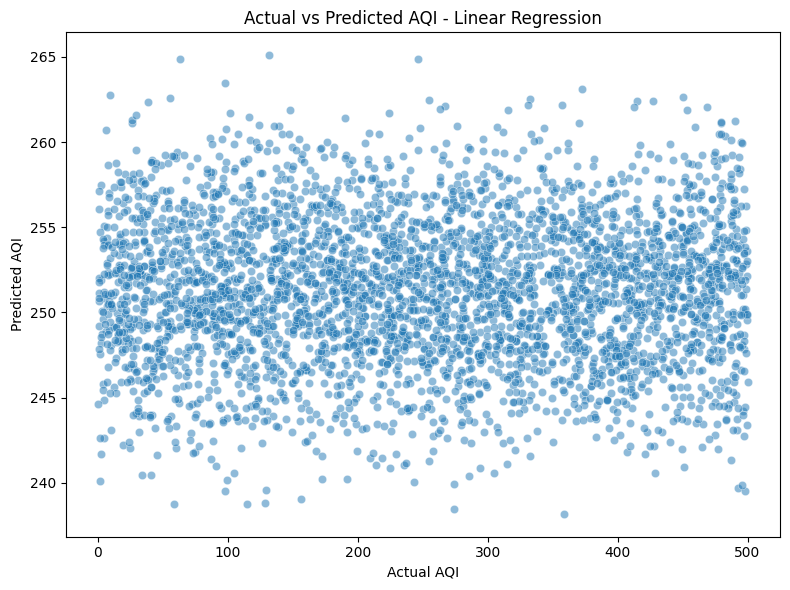

In [91]:
#Plot actual vs predicted: Linear Regression
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_linear,
    alpha=0.5
)

plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI - Linear Regression')

plt.tight_layout()
plt.savefig('figures/figure_7_linear_actual_vs_predicted.png', dpi=300)
plt.show()

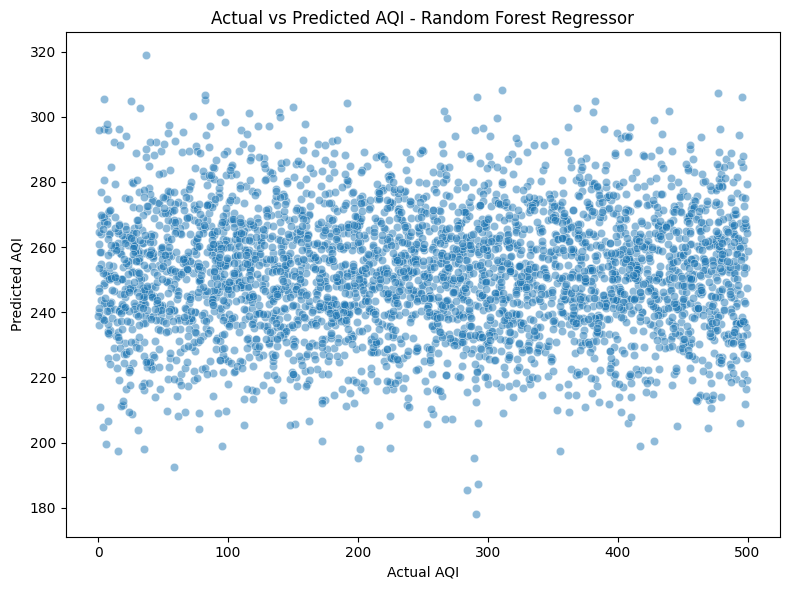

In [92]:
#Plot actual vs predicted: Random Forest
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_rf,
    alpha=0.5
)

plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI - Random Forest Regressor')

plt.tight_layout()
plt.savefig('figures/figure_8_rf_actual_vs_predicted.png', dpi=300)
plt.show()

In [93]:
#Overfitting and Underfitting Analysis
#Generate training predictions
y_train_pred_linear = linear_regression_model.predict(X_train)
y_train_pred_rf = random_forest_model.predict(X_train)

print("Training predictions generated successfully.")

Training predictions generated successfully.


In [94]:
#Calculate training and testing R²
linear_train_r2 = r2_score(y_train, y_train_pred_linear)
linear_test_r2 = r2_score(y_test, y_pred_linear)

rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_pred_rf)

print("Linear Regression")
print("Training R²:", round(linear_train_r2, 4))
print("Testing R²:", round(linear_test_r2, 4))

print("\nRandom Forest Regressor")
print("Training R²:", round(rf_train_r2, 4))
print("Testing R²:", round(rf_test_r2, 4))

Linear Regression
Training R²: 0.0009
Testing R²: -0.0016

Random Forest Regressor
Training R²: 0.8583
Testing R²: -0.0187


In [95]:
#Calculate complete train/test comparison
train_test_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regressor'
    ],
    'Train_R2': [
        linear_train_r2,
        rf_train_r2
    ],
    'Test_R2': [
        linear_test_r2,
        rf_test_r2
    ]
})

train_test_results['R2_Gap'] = (
    train_test_results['Train_R2'] -
    train_test_results['Test_R2']
)

train_test_results

,Model,Train_R2,Test_R2,R2_Gap
0,Linear Regression,0.000906,-0.001619,0.002524
1,Random Forest Regressor,0.858317,-0.018716,0.877033


In [96]:
#Calculating training and testing errors
linear_train_mae = mean_absolute_error(y_train, y_train_pred_linear)
linear_test_mae = mean_absolute_error(y_test, y_pred_linear)

rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_test_mae = mean_absolute_error(y_test, y_pred_rf)

error_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regressor'
    ],
    'Train_MAE': [
        linear_train_mae,
        rf_train_mae
    ],
    'Test_MAE': [
        linear_test_mae,
        rf_test_mae
    ]
})

error_comparison

,Model,Train_MAE,Test_MAE
0,Linear Regression,125.154746,124.717032
1,Random Forest Regressor,46.564253,125.486999


In [97]:
#Save overfitting analysis
train_test_results.to_csv(
    'outputs/train_test_r2_comparison.csv',
    index=False
)

error_comparison.to_csv(
    'outputs/train_test_mae_comparison.csv',
    index=False
)

In [98]:
#Extract Random Forest feature importance
rf_model = random_forest_model.named_steps['model']

rf_importances = rf_model.feature_importances_

rf_feature_importance = pd.DataFrame({
    'Feature': final_feature_names,
    'Importance': rf_importances
})

rf_feature_importance = rf_feature_importance.sort_values(
    by='Importance',
    ascending=False
)

rf_feature_importance

,Feature,Importance
10,Toluene,0.070390
9,Benzene,0.069914
1,PM10,0.069641
3,NO2,0.069507
0,PM2.5,0.069491
4,NOx,0.069035
6,CO,0.068825
2,NO,0.067654
7,SO2,0.067635
5,NH3,0.067631


In [99]:
#Display the top 10 features
top_10_features = rf_feature_importance.head(10)

print(top_10_features)

    Feature  Importance
10  Toluene    0.070390
9   Benzene    0.069914
1      PM10    0.069641
3       NO2    0.069507
0     PM2.5    0.069491
4       NOx    0.069035
6        CO    0.068825
2        NO    0.067654
7       SO2    0.067635
5       NH3    0.067631


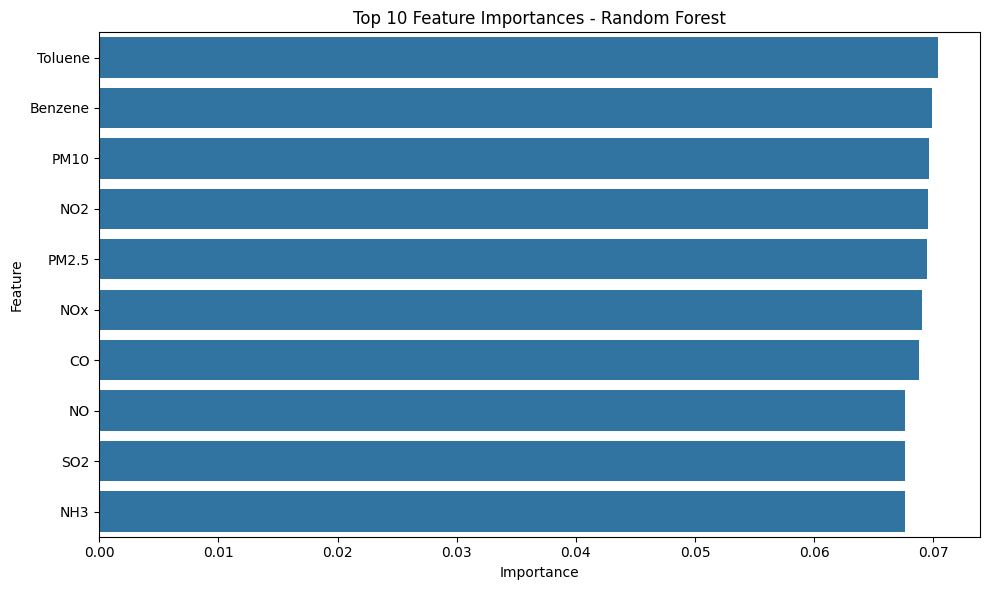

In [100]:
#Plot the top 10 features importances
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.savefig('figures/figure_9_random_forest_feature_importance.png', dpi=300)
plt.show()

In [101]:
#Save feature importance results
rf_feature_importance.to_csv(
    'outputs/random_forest_feature_importance.csv',
    index=False
)

In [102]:
#Check cumulative importance
rf_feature_importance['Cumulative_Importance'] = (
    rf_feature_importance['Importance'].cumsum()
)

rf_feature_importance.head(10)

,Feature,Importance,Cumulative_Importance
10,Toluene,0.070390,0.070390
9,Benzene,0.069914,0.140304
1,PM10,0.069641,0.209946
3,NO2,0.069507,0.279452
0,PM2.5,0.069491,0.348943
4,NOx,0.069035,0.417978
6,CO,0.068825,0.486803
2,NO,0.067654,0.554456
7,SO2,0.067635,0.622091
5,NH3,0.067631,0.689722


In [103]:
#Residual Analysis
#Calculate residuals
residuals_linear = y_test - y_pred_linear
residuals_rf = y_test - y_pred_rf

In [104]:
#Residual statistics
residual_summary = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regressor'
    ],
    'Mean_Residual': [
        residuals_linear.mean(),
        residuals_rf.mean()
    ],
    'Std_Residual': [
        residuals_linear.std(),
        residuals_rf.std()
    ],
    'Min_Residual': [
        residuals_linear.min(),
        residuals_rf.min()
    ],
    'Max_Residual': [
        residuals_linear.max(),
        residuals_rf.max()
    ]
})

residual_summary

,Model,Mean_Residual,Std_Residual,Min_Residual,Max_Residual
0,Linear Regression,-0.984819,144.386077,-256.443597,258.783762
1,Random Forest Regressor,-1.629268,145.607436,-301.125000,287.997000


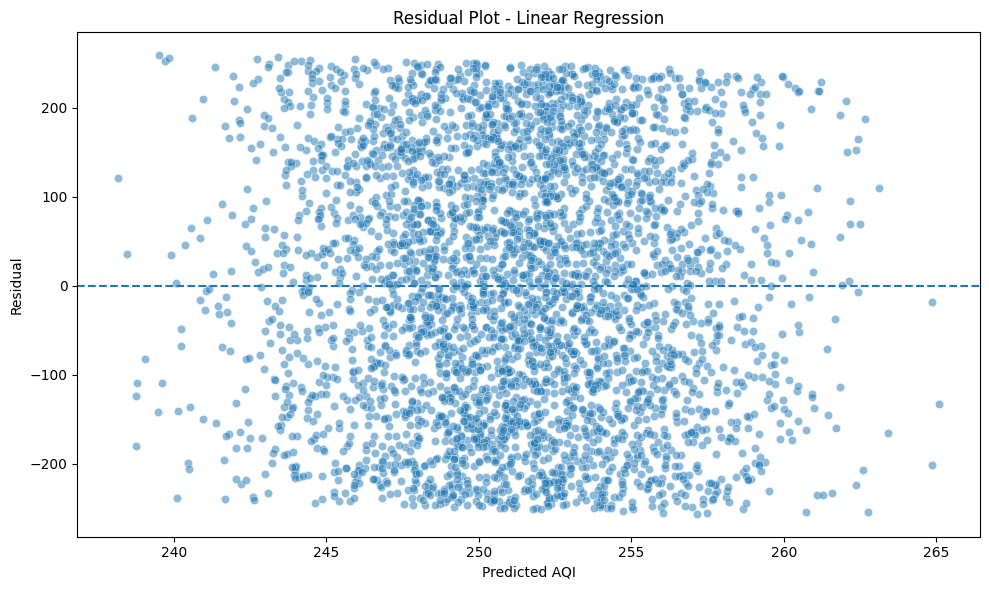

In [105]:
#Linear Regression residual plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred_linear,
    y=residuals_linear,
    alpha=0.5
)

plt.axhline(0, linestyle='--')

plt.title('Residual Plot - Linear Regression')
plt.xlabel('Predicted AQI')
plt.ylabel('Residual')

plt.tight_layout()
plt.savefig('figures/figure_10_linear_residuals.png', dpi=300)
plt.show()

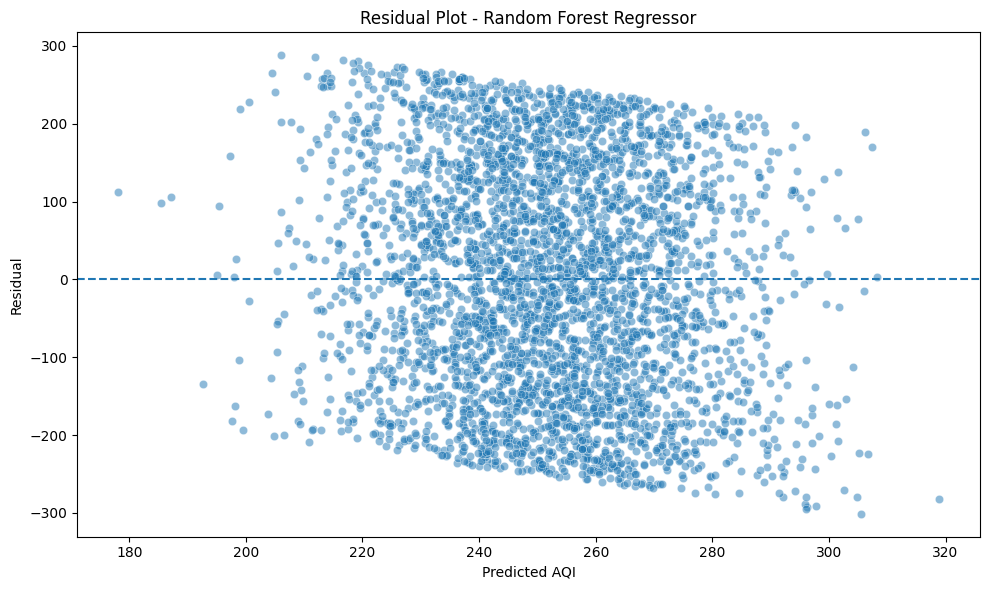

In [106]:
#Random Forest residual plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred_rf,
    y=residuals_rf,
    alpha=0.5
)

plt.axhline(0, linestyle='--')

plt.title('Residual Plot - Random Forest Regressor')
plt.xlabel('Predicted AQI')
plt.ylabel('Residual')

plt.tight_layout()
plt.savefig('figures/figure_11_rf_residuals.png', dpi=300)
plt.show()

In [108]:
#Save residual results
residual_summary.to_csv(
    'outputs/residual_analysis.csv',
    index=False
)

In [109]:
#Actual vs Predicted Summary
#Prediction summary statistics
prediction_summary = pd.DataFrame({
    'Actual_AQI': y_test,
    'Linear_Predicted_AQI': y_pred_linear,
    'Random_Forest_Predicted_AQI': y_pred_rf
})

prediction_summary.describe()

,Actual_AQI,Linear_Predicted_AQI,Random_Forest_Predicted_AQI
count,3653.000000,3653.000000,3653.000000
mean,250.234656,251.219476,251.863925
std,144.272721,4.272243,19.080233
min,0.100000,238.172662,178.119000
25%,124.600000,248.273886,239.153000
50%,249.700000,251.245472,251.896000
75%,375.200000,254.126015,264.608000
max,500.000000,265.093132,318.871000


In [110]:
#Save predictions
prediction_summary.to_csv(
    'outputs/test_set_predictions.csv',
    index=False
)

In [111]:
#Final Model Comparison
#Complete model comparison table
final_model_comparison = results.copy()

final_model_comparison['Train_R2'] = [
    linear_train_r2,
    rf_train_r2
]

final_model_comparison['R2_Gap'] = (
    final_model_comparison['Train_R2'] -
    final_model_comparison['R2']
)

final_model_comparison

,Model,MAE,MSE,RMSE,R2,Train_R2,R2_Gap
0,Linear Regression,124.717032,20842.602336,144.369672,-0.001619,0.000906,0.002524
1,Random Forest Regressor,125.486999,21198.376072,145.596621,-0.018716,0.858317,0.877033


In [112]:
#Round the results
final_model_comparison_rounded = final_model_comparison.copy()

numeric_columns = [
    'MAE',
    'MSE',
    'RMSE',
    'R2',
    'Train_R2',
    'R2_Gap'
]

final_model_comparison_rounded[numeric_columns] = (
    final_model_comparison_rounded[numeric_columns].round(4)
)

final_model_comparison_rounded

,Model,MAE,MSE,RMSE,R2,Train_R2,R2_Gap
0,Linear Regression,124.717,20842.6023,144.3697,-0.0016,0.0009,0.0025
1,Random Forest Regressor,125.487,21198.3761,145.5966,-0.0187,0.8583,0.8770


In [113]:
#Save final model comparison
final_model_comparison_rounded.to_csv(
    'outputs/final_model_comparison.csv',
    index=False
)

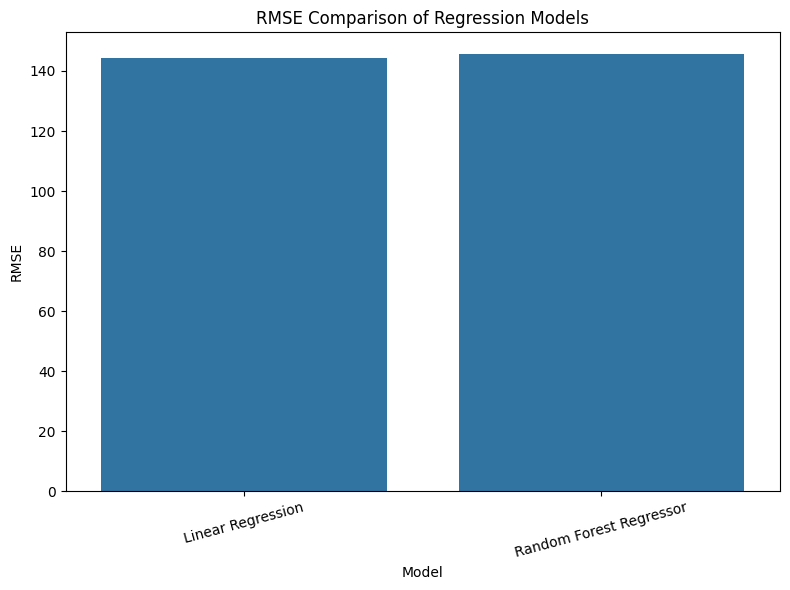

In [114]:
#Model Performance Visualization
#Compare RMSE
plt.figure(figsize=(8, 6))

sns.barplot(
    data=final_model_comparison,
    x='Model',
    y='RMSE'
)

plt.title('RMSE Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('figures/figure_12_model_rmse_comparison.png', dpi=300)
plt.show()

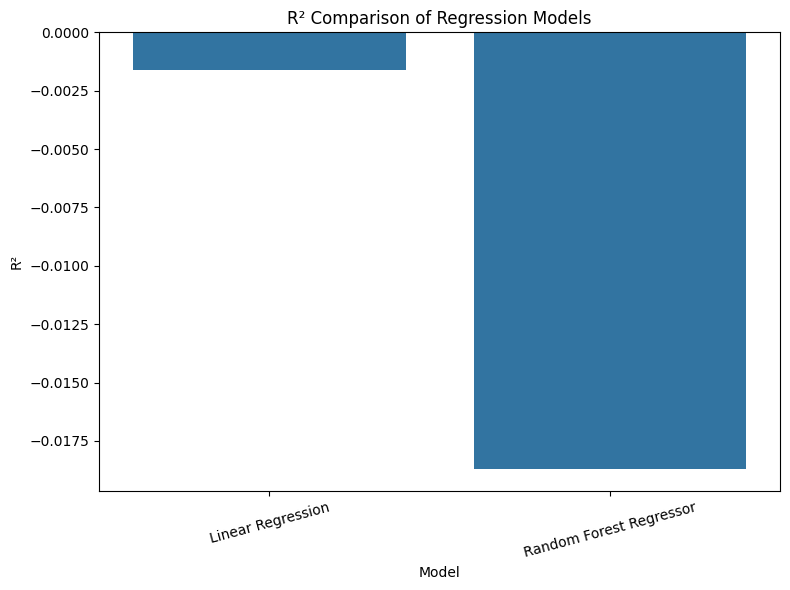

In [115]:
#Compare R²
plt.figure(figsize=(8, 6))

sns.barplot(
    data=final_model_comparison,
    x='Model',
    y='R2'
)

plt.title('R² Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('R²')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('figures/figure_13_model_r2_comparison.png', dpi=300)
plt.show()

In [116]:
#Check Model Errors
#Error comparison
error_comparison_final = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regressor'
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    'R2': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_rf)
    ]
})

error_comparison_final.round(4)

,Model,MAE,RMSE,R2
0,Linear Regression,124.717,144.3697,-0.0016
1,Random Forest Regressor,125.487,145.5966,-0.0187


In [117]:
#save final errors
error_comparison_final.to_csv(
    'outputs/final_error_comparison.csv',
    index=False
)

In [118]:
#Final Dataset and Feature Verification
#Verify final predictors
print("Target variable:", target)

print("\nNumber of original input features:", len(feature_columns))

print("\nInput features:")
for feature in feature_columns:
    print("-", feature)

print("\nAQI included in features:", 'AQI' in feature_columns)
print("AQI_Bucket included in features:", 'AQI_Bucket' in feature_columns)

Target variable: AQI

Number of original input features: 17

Input features:
- City
- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene
- Xylene
- Year
- Month
- Day
- DayOfWeek

AQI included in features: False
AQI_Bucket included in features: False


In [119]:
#Final Dataset Summary
final_summary = {
    'Total Observations': len(df_clean),
    'Original Columns': 16,
    'Model Input Columns Before Encoding': len(feature_columns),
    'Final Features After Encoding': len(final_feature_names),
    'Number of Cities': df_clean['City'].nunique(),
    'Target Variable': target,
    'Training Observations': len(X_train),
    'Testing Observations': len(X_test),
    'Missing Values': int(df_clean.isnull().sum().sum()),
    'Duplicate Rows': int(df_clean.duplicated().sum())
}

for key, value in final_summary.items():
    print(f"{key}: {value}")

Total Observations: 18265
Original Columns: 16
Model Input Columns Before Encoding: 17
Final Features After Encoding: 21
Number of Cities: 5
Target Variable: AQI
Training Observations: 14612
Testing Observations: 3653
Missing Values: 0
Duplicate Rows: 0


In [120]:
os.makedirs('outputs/final', exist_ok=True)

In [122]:
aqi_by_city.to_csv(
    'outputs/final/aqi_by_city.csv'
)

correlation_summary.to_csv(
    'outputs/final/correlation_summary.csv',
    index=False
)

feature_engineering_summary.to_csv(
    'outputs/final/feature_engineering_summary.csv',
    index=False
)

final_model_comparison_rounded.to_csv(
    'outputs/final/model_comparison.csv',
    index=False
)

residual_summary.to_csv(
    'outputs/final/residual_summary.csv',
    index=False
)

rf_feature_importance.to_csv(
    'outputs/final/feature_importance.csv',
    index=False
)

prediction_summary.to_csv(
    'outputs/final/test_predictions.csv',
    index=False
)

print("All important analysis results saved successfully.")

All important analysis results saved successfully.


In [124]:
print("\n1. Dataset")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\n2. Data Quality")
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

print("\n3. Target")
print("Target:", target)
print("Target in X:", target in X.columns)
print("AQI_Bucket in X:", 'AQI_Bucket' in X.columns)

print("\n4. Train-Test Split")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\n5. Models")
print("Linear Regression: Trained")
print("Random Forest Regressor: Trained")

print("\n6. Evaluation")
print("Evaluation metrics: MAE, MSE, RMSE, R²")

print("\n7. Outputs")
print("Figures saved:", len(os.listdir('figures')))
print("Output files saved:", len(os.listdir('outputs')))


1. Dataset
Rows: 18265
Columns: 20

2. Data Quality
Missing values: 0
Duplicate rows: 0

3. Target
Target: AQI
Target in X: False
AQI_Bucket in X: False

4. Train-Test Split
Training rows: 14612
Testing rows: 3653

5. Models
Linear Regression: Trained
Random Forest Regressor: Trained

6. Evaluation
Evaluation metrics: MAE, MSE, RMSE, R²

7. Outputs
Figures saved: 13
Output files saved: 14
